In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [ ]:
# Image processing
from PIL import Image
import cv2

In [ ]:
# Scientific computing
import numpy as np
import pandas as pd

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# System utilities
import os
import sys
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict, Counter
import time
import pickle
import json

In [ ]:
# Google Colab specific
from google.colab import drive, files

In [ ]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    """
    Set random seeds for reproducible results.
    This ensures your experiments give the same results each time.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    import random
    random.seed(seed)
    # Make PyTorch deterministic (slightly slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("\n✓ Random seeds set (seed=42) for reproducibility")


✓ Random seeds set (seed=42) for reproducibility


In [ ]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\n" + "="*60)
print("🖥️  HARDWARE CHECK")
print("="*60)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️  No GPU detected - training will be slow!")
    print("   Go to Runtime → Change runtime type → Select GPU")


🖥️  HARDWARE CHECK
Device: cuda
GPU: NVIDIA L4
GPU Memory: 23.80 GB
CUDA Version: 12.6


In [ ]:
!pip install kagglehub opencv-python matplotlib -q

In [ ]:
import os
import kagglehub
import matplotlib.pyplot as plt
import cv2
import numpy as np

# 1) Download latest version of the VGGFace2 dataset from Kaggle
path = kagglehub.dataset_download("hearfool/vggface2")

print("Path to dataset files:", path)
print("Top-level content:", os.listdir(path))


Using Colab cache for faster access to the 'vggface2' dataset.
Path to dataset files: /kaggle/input/vggface2
Top-level content: ['val', 'train']


In [ ]:
# List top-level contents
print("Top-level items in dataset path:")
for item in os.listdir(path):
    print("-", item)

Top-level items in dataset path:
- val
- train


In [ ]:
# Adjust this string depending on what you saw in STEP 2
train_root = os.path.join(path, "train")  # or "vggface2_train", etc.

print("Train root:", train_root)
print("Number of identities (folders) in train:")

identity_folders = sorted([d for d in os.listdir(train_root)
                           if os.path.isdir(os.path.join(train_root, d))])

print("Total identities:", len(identity_folders))
print("First 10 identities:", identity_folders[:10])

Train root: /kaggle/input/vggface2/train
Number of identities (folders) in train:
Total identities: 480
First 10 identities: ['n000002', 'n000003', 'n000004', 'n000005', 'n000006', 'n000007', 'n000008', 'n000010', 'n000011', 'n000012']


Random identity: n000122
Images in this identity folder: 365


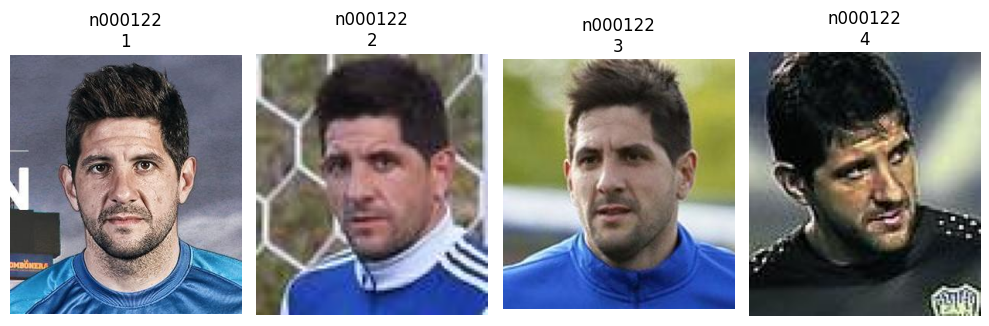

In [ ]:
import random # Add this line to import the random module
import glob # Add this line to import the glob module

# Pick a random identity
random_id = random.choice(identity_folders)
id_dir = os.path.join(train_root, random_id)
print("Random identity:", random_id)
print("Images in this identity folder:", len(os.listdir(id_dir)))

# Get a few image paths
image_paths = glob.glob(os.path.join(id_dir, "*.jpg"))
image_paths = image_paths[:4]  # first 4 images

# Plot them
plt.figure(figsize=(10, 5))
for i, img_path in enumerate(image_paths):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{random_id}\n{i+1}")
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import random
from collections import Counter

# Use the same train_root you already found
# Example (if not already defined):
# train_root = os.path.join(path, "train")

print("Train root:", train_root)

identity_folders = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d))
])

print("Total identities in full train:", len(identity_folders))


Train root: /kaggle/input/vggface2/train
Total identities in full train: 480


In [ ]:
# Count images per identity
id_to_imgs = {}
for person_id in identity_folders:
    person_dir = os.path.join(train_root, person_id)
    img_paths = glob.glob(os.path.join(person_dir, "*.jpg"))
    if len(img_paths) > 0:
        id_to_imgs[person_id] = img_paths

print("Identities with at least 1 image:", len(id_to_imgs))

# Filter identities with at least N images
MIN_IMAGES_PER_ID = 20
eligible_ids = [pid for pid, imgs in id_to_imgs.items() if len(imgs) >= MIN_IMAGES_PER_ID]

print(f"Identities with ≥{MIN_IMAGES_PER_ID} images:", len(eligible_ids))

# Pick a subset
NUM_IDENTITIES = 30  # you can change this (e.g., 50)
subset_ids = random.sample(eligible_ids, k=min(NUM_IDENTITIES, len(eligible_ids)))

print("Using these identities (subset):")
print(subset_ids)


Identities with at least 1 image: 480
Identities with ≥20 images: 480
Using these identities (subset):
['n000076', 'n000396', 'n000057', 'n000364', 'n000398', 'n000478', 'n000296', 'n000049', 'n000319', 'n000231', 'n000019', 'n000018', 'n000052', 'n000119', 'n000127', 'n000274', 'n000325', 'n000016', 'n000304', 'n000109', 'n000384', 'n000349', 'n000377', 'n000229', 'n000120', 'n000244', 'n000318', 'n000155', 'n000435', 'n000467']


In [ ]:
from PIL import Image

label_map = {pid: idx for idx, pid in enumerate(sorted(subset_ids))}
num_classes = len(label_map)
print("Number of classes in subset:", num_classes)

all_samples = []  # list of (img_path, label)

for pid in subset_ids:
    imgs = id_to_imgs[pid]
    label = label_map[pid]
    for img_path in imgs:
        all_samples.append((img_path, label))

print("Total raw samples (before cleaning):", len(all_samples))

Number of classes in subset: 30
Total raw samples (before cleaning): 10041


In [ ]:
clean_samples = []

for img_path, label in all_samples:
    try:
        with Image.open(img_path) as im:
            im.verify()  # quick check: verifies but doesn't fully decode
        clean_samples.append((img_path, label))
    except Exception as e:
        # If corrupted, just skip it
        print(f"Skipping corrupted image: {img_path} | Error: {e}")

print("Total samples after cleaning:", len(clean_samples))


Total samples after cleaning: 10041


In [ ]:
from collections import defaultdict
import math

# Group by label
by_label = defaultdict(list)
for img_path, label in clean_samples:
    by_label[label].append(img_path)

train_samples = []
val_samples = []

train_ratio = 0.8

for label, paths in by_label.items():
    random.shuffle(paths)
    n = len(paths)
    n_train = max(1, int(train_ratio * n))
    train_paths = paths[:n_train]
    val_paths = paths[n_train:]

    train_samples.extend([(p, label) for p in train_paths])
    val_samples.extend([(p, label) for p in val_paths])

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))

Train samples: 8021
Val samples: 2020


In [ ]:
train_counts = Counter([lbl for _, lbl in train_samples])
val_counts = Counter([lbl for _, lbl in val_samples])

print("Train class counts:", train_counts)
print("Val class counts:", val_counts)

Train class counts: Counter({18: 385, 7: 382, 23: 378, 15: 369, 0: 359, 3: 352, 27: 336, 9: 333, 29: 312, 2: 299, 28: 293, 5: 292, 19: 284, 14: 267, 25: 245, 6: 243, 11: 232, 1: 226, 16: 220, 24: 220, 26: 218, 17: 217, 10: 216, 12: 216, 22: 215, 13: 208, 20: 203, 4: 169, 21: 167, 8: 165})
Val class counts: Counter({18: 97, 7: 96, 23: 95, 15: 93, 0: 90, 3: 88, 9: 84, 27: 84, 29: 78, 2: 75, 28: 74, 5: 73, 19: 71, 14: 67, 25: 62, 6: 61, 11: 59, 1: 57, 16: 56, 24: 56, 26: 55, 10: 55, 17: 55, 12: 55, 22: 54, 13: 52, 20: 51, 4: 43, 8: 42, 21: 42})


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Transforms (we can tweak later for Siamese / Triplet)
IMG_SIZE = 160  # good for FaceNet-style models; we can change later

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

class VGGFace2Subset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples  # list of (path, label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label


In [ ]:
train_dataset = VGGFace2Subset(train_samples, transform=transform_train)
val_dataset   = VGGFace2Subset(val_samples,   transform=transform_val)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 251
Val batches: 64


Batch shape: torch.Size([32, 3, 160, 160])
Batch labels: tensor([ 1,  4, 23, 13, 15, 13,  1, 22, 28, 11])


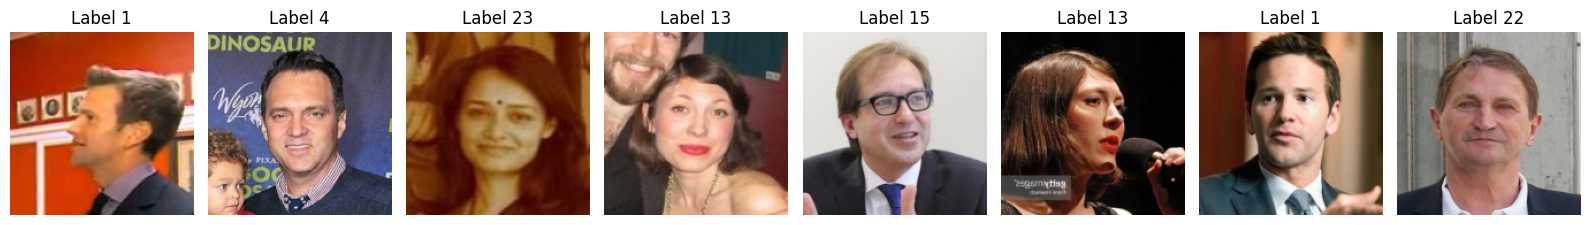

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Get one batch
batch_imgs, batch_labels = next(iter(train_loader))
print("Batch shape:", batch_imgs.shape)
print("Batch labels:", batch_labels[:10])

# Inverse normalization for visualization
def denormalize(img_tensor):
    # img_tensor: (C, H, W)
    img = img_tensor.clone()
    img = img * 0.5 + 0.5  # since we used mean=0.5, std=0.5
    img = img.clamp(0, 1)
    return img

# Show first 8 images
n_show = 8
plt.figure(figsize=(16, 4))
for i in range(n_show):
    img = denormalize(batch_imgs[i]).permute(1, 2, 0).numpy()
    label = batch_labels[i].item()
    plt.subplot(1, n_show, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label {label}")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class MobileNetEmbeddingNet(nn.Module):
    def __init__(self, embedding_size=128):
        super().__init__()

        # 1. Load pretrained MobileNetV2 backbone
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        # 2. Take everything except the classifier
        self.features = backbone.features  # convolutional feature extractor

        # 3. Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 4. MobileNetV2's last conv block outputs 1280 channels
        self.embedding_layer = nn.Linear(1280, embedding_size)

        # L2-normalize embeddings (important for cosine similarity / triplet loss)
        self.l2_norm = nn.functional.normalize

    def forward(self, x):
        x = self.features(x)               # (B, 1280, H', W')
        x = self.avgpool(x)                # (B, 1280, 1, 1)
        x = x.view(x.size(0), -1)          # (B, 1280)
        x = self.embedding_layer(x)        # (B, embedding_size)
        x = self.l2_norm(x, p=2, dim=1)    # unit-length embeddings
        return x


In [ ]:
model = MobileNetEmbeddingNet(embedding_size=128)

batch_imgs, batch_labels = next(iter(train_loader))
embeddings = model(batch_imgs)

print("Input batch:", batch_imgs.shape)
print("Embedding output:", embeddings.shape)
print("First 3 L2 norms:", torch.norm(embeddings[:3], dim=1))


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 130MB/s]


Input batch: torch.Size([32, 3, 160, 160])
Embedding output: torch.Size([32, 128])
First 3 L2 norms: tensor([1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)


In [ ]:
from torch.utils.data import Dataset, DataLoader
import random
from PIL import Image

class TripletVGGFace2(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: list of (img_path, label)
        """
        self.samples = samples
        self.transform = transform

        # Build label -> indices mapping
        self.label_to_indices = {}
        for idx, (_, label) in enumerate(self.samples):
            self.label_to_indices.setdefault(label, []).append(idx)

        self.labels = list(self.label_to_indices.keys())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        # Anchor
        anchor_path, anchor_label = self.samples[index]
        anchor_img = Image.open(anchor_path).convert("RGB")

        # Positive (same label, different image)
        positive_indices = self.label_to_indices[anchor_label]
        if len(positive_indices) == 1:
            pos_index = positive_indices[0]
        else:
            pos_index = random.choice([i for i in positive_indices if i != index])

        positive_path, _ = self.samples[pos_index]
        positive_img = Image.open(positive_path).convert("RGB")

        # Negative (different label)
        neg_label = random.choice([lbl for lbl in self.labels if lbl != anchor_label])
        neg_index = random.choice(self.label_to_indices[neg_label])
        negative_path, _ = self.samples[neg_index]
        negative_img = Image.open(negative_path).convert("RGB")

        # Apply transforms
        if self.transform is not None:
            anchor_img   = self.transform(anchor_img)
            positive_img = self.transform(positive_img)
            negative_img = self.transform(negative_img)

        return anchor_img, positive_img, negative_img


In [ ]:
triplet_train_dataset = TripletVGGFace2(train_samples, transform=transform_train)

TRIPLET_BATCH_SIZE = 32

triplet_train_loader = DataLoader(
    triplet_train_dataset,
    batch_size=TRIPLET_BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# Quick sanity check
a, p, n = next(iter(triplet_train_loader))
print("Anchor batch:", a.shape)
print("Positive batch:", p.shape)
print("Negative batch:", n.shape)


Anchor batch: torch.Size([32, 3, 160, 160])
Positive batch: torch.Size([32, 3, 160, 160])
Negative batch: torch.Size([32, 3, 160, 160])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = MobileNetEmbeddingNet(embedding_size=128).to(device)

triplet_loss_fn = nn.TripletMarginLoss(margin=0.3, p=2)  # margin α from your slide
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0

    for batch_idx, (anchor, positive, negative) in enumerate(loader):
        anchor   = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        # Forward pass through embedding network
        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n = model(negative)

        loss = loss_fn(emb_a, emb_p, emb_n)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Batch {batch_idx+1}/{len(loader)}  Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(loader)
    print(f"Epoch finished. Avg loss: {avg_loss:.4f}")
    return avg_loss


In [ ]:
epoch_loss = train_one_epoch(model, triplet_train_loader, optimizer, triplet_loss_fn, device)

Batch 50/251  Loss: 0.1450
Batch 100/251  Loss: 0.0718
Batch 150/251  Loss: 0.0390
Batch 200/251  Loss: 0.0928
Batch 250/251  Loss: 0.0394
Epoch finished. Avg loss: 0.0789


In [ ]:
NUM_EPOCHS = 5  # you can change later
best_loss = float("inf")
save_path = "mobilenet_triplet_vggface2.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    epoch_loss = train_one_epoch(model, triplet_train_loader,optimizer, triplet_loss_fn, device)

    # Save best model so far
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), save_path)
        print(f"✔ New best loss {best_loss:.4f}, model saved to {save_path}")
    else:
        print(f"(No improvement, best loss still {best_loss:.4f})")



=== Epoch 1/5 ===
Batch 50/251  Loss: 0.0565
Batch 100/251  Loss: 0.0499
Batch 150/251  Loss: 0.0813
Batch 200/251  Loss: 0.0159
Batch 250/251  Loss: 0.0280
Epoch finished. Avg loss: 0.0411
✔ New best loss 0.0411, model saved to mobilenet_triplet_vggface2.pt

=== Epoch 2/5 ===
Batch 50/251  Loss: 0.0144
Batch 100/251  Loss: 0.0452
Batch 150/251  Loss: 0.0400
Batch 200/251  Loss: 0.0585
Batch 250/251  Loss: 0.0197
Epoch finished. Avg loss: 0.0299
✔ New best loss 0.0299, model saved to mobilenet_triplet_vggface2.pt

=== Epoch 3/5 ===
Batch 50/251  Loss: 0.0234
Batch 100/251  Loss: 0.0410
Batch 150/251  Loss: 0.0443
Batch 200/251  Loss: 0.0226
Batch 250/251  Loss: 0.0343
Epoch finished. Avg loss: 0.0219
✔ New best loss 0.0219, model saved to mobilenet_triplet_vggface2.pt

=== Epoch 4/5 ===
Batch 50/251  Loss: 0.0461
Batch 100/251  Loss: 0.0084
Batch 150/251  Loss: 0.0000
Batch 200/251  Loss: 0.0121
Batch 250/251  Loss: 0.0149
Epoch finished. Avg loss: 0.0210
✔ New best loss 0.0210, model

In [ ]:
best_model = MobileNetEmbeddingNet(embedding_size=128).to(device)
best_model.load_state_dict(torch.load(save_path, map_location=device))
best_model.eval()
print("Loaded best model from", save_path)

Loaded best model from mobilenet_triplet_vggface2.pt


In [ ]:
from collections import defaultdict

# val_samples came from earlier steps (list of (path, label))
by_label_val = defaultdict(list)
for img_path, label in val_samples:
    by_label_val[label].append(img_path)

gallery = []  # list of (img_path, label)
probe   = []  # list of (img_path, label)

for label, paths in by_label_val.items():
    if len(paths) < 2:
        # not enough images to form gallery+probe, skip this identity
        continue
    # deterministic: first as gallery, rest as probe
    paths = sorted(paths)
    gallery.append((paths[0], label))
    for p in paths[1:]:
        probe.append((p, label))

print("Gallery size:", len(gallery))
print("Probe size:", len(probe))


Gallery size: 30
Probe size: 1990


In [ ]:
from torch.utils.data import Dataset, DataLoader

class SimpleImageDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label


def compute_embeddings(model, samples, transform, device, batch_size=64):
    dataset = SimpleImageDataset(samples, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_embs = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            embs = model(imgs)          # (B, 128)
            all_embs.append(embs.cpu())
            all_labels.append(labels)

    all_embs = torch.cat(all_embs, dim=0)       # (N, 128)
    all_labels = torch.cat(all_labels, dim=0)   # (N,)
    return all_embs, all_labels


In [ ]:
import torch.nn.functional as F

gallery_embs, gallery_labels = compute_embeddings(
    best_model, gallery, transform_val, device
)
probe_embs, probe_labels = compute_embeddings(
    best_model, probe, transform_val, device
)

print("Gallery embeddings:", gallery_embs.shape)
print("Probe embeddings:", probe_embs.shape)


Gallery embeddings: torch.Size([30, 128])
Probe embeddings: torch.Size([1990, 128])


In [ ]:
def evaluate_nn(gallery_embs, gallery_labels, probe_embs, probe_labels):
    # Normalize again just in case
    gallery_embs_n = F.normalize(gallery_embs, p=2, dim=1)
    probe_embs_n   = F.normalize(probe_embs,   p=2, dim=1)

    correct = 0
    total = probe_embs_n.size(0)

    # Precompute transpose for faster matmul
    gallery_T = gallery_embs_n.t()   # (128, G)

    with torch.no_grad():
        # Compute similarity of all probes to all gallery embeddings
        # result: (P, G)
        sims = torch.matmul(probe_embs_n, gallery_T)

        # For each probe, find index of best gallery
        best_idx = torch.argmax(sims, dim=1)          # (P,)
        pred_labels = gallery_labels[best_idx]        # (P,)

        correct = (pred_labels == probe_labels).sum().item()

    acc = correct / total if total > 0 else 0.0
    print(f"Nearest-neighbor identification accuracy: {acc*100:.2f}% "
          f"({correct}/{total})")
    return acc


In [ ]:
acc = evaluate_nn(gallery_embs, gallery_labels, probe_embs, probe_labels)


Nearest-neighbor identification accuracy: 81.21% (1616/1990)


In [ ]:
import torch
import torch.nn.functional as F

class EmbeddingDatabase:
    def __init__(self, threshold=0.55):
        """
        threshold: cosine similarity threshold for deciding if a face matches
        an existing identity.
        Typical values: 0.4–0.7 depending on embedding strength.
        """
        self.db = {}  # {name: [embedding tensors]}
        self.threshold = threshold

    def add_identity(self, name, embedding):
        """Add a new embedding for the given name."""
        emb = embedding.detach().cpu().float()
        if name not in self.db:
            self.db[name] = []
        self.db[name].append(emb)
        print(f"Added embedding to identity '{name}'. Total embeddings: {len(self.db[name])}")

    def get_all_identities(self):
        return list(self.db.keys())

    def recognize(self, embedding):
        """
        Compare an embedding to all stored faces and return:
        - best_name, best_similarity
        or ("Unknown", similarity) if below threshold.
        """
        embedding = embedding.detach().cpu()
        best_name = None
        best_sim = -1  # lowest possible cosine similarity

        for name, emb_list in self.db.items():
            # Compute similarity against all embeddings for this identity
            embs = torch.stack(emb_list)  # shape: (N, 128)
            sims = F.cosine_similarity(embedding.unsqueeze(0), embs)  # (N,)
            max_sim = sims.max().item()

            if max_sim > best_sim:
                best_sim = max_sim
                best_name = name

        # Decide if this is known or unknown
        if best_sim >= self.threshold:
            return best_name, best_sim
        else:
            return "Unknown", best_sim


In [ ]:
db = EmbeddingDatabase(threshold=0.55)

# Add gallery samples to the database
best_model.eval()
with torch.no_grad():
    for img_path, label in gallery:
        img = Image.open(img_path).convert("RGB")
        img = transform_val(img).unsqueeze(0).to(device)
        emb = best_model(img)

        name = f"person_{label}"
        db.add_identity(name, emb)


Added embedding to identity 'person_6'. Total embeddings: 1
Added embedding to identity 'person_25'. Total embeddings: 1
Added embedding to identity 'person_5'. Total embeddings: 1
Added embedding to identity 'person_22'. Total embeddings: 1
Added embedding to identity 'person_26'. Total embeddings: 1
Added embedding to identity 'person_29'. Total embeddings: 1
Added embedding to identity 'person_16'. Total embeddings: 1
Added embedding to identity 'person_3'. Total embeddings: 1
Added embedding to identity 'person_19'. Total embeddings: 1
Added embedding to identity 'person_13'. Total embeddings: 1
Added embedding to identity 'person_2'. Total embeddings: 1
Added embedding to identity 'person_1'. Total embeddings: 1
Added embedding to identity 'person_4'. Total embeddings: 1
Added embedding to identity 'person_8'. Total embeddings: 1
Added embedding to identity 'person_10'. Total embeddings: 1
Added embedding to identity 'person_15'. Total embeddings: 1
Added embedding to identity 'pe

In [ ]:
correct = 0

for img_path, true_label in probe[:50]:  # test with 50 random images first
    img = Image.open(img_path).convert("RGB")
    img = transform_val(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = best_model(img)

    predicted_name, sim = db.recognize(emb)
    true_name = f"person_{true_label}"

    print(f"True: {true_name} | Predicted: {predicted_name} | sim={sim:.3f}")

    if predicted_name == true_name:
        correct += 1

print(f"\nSmall test accuracy: {correct}/50 = {correct/50*100:.2f}%")


True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Predicted: person_6 | sim=1.000
True: person_6 | Pre

In [ ]:
(path, label)  # label is an integer: 0,1,2,...


('/kaggle/input/vggface2', 28)

Sample labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


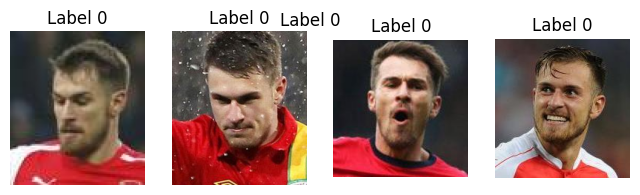

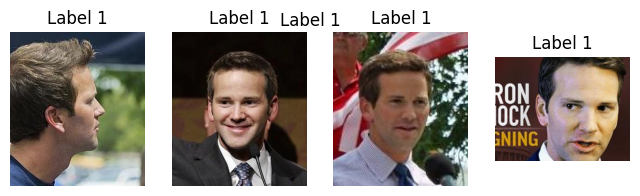

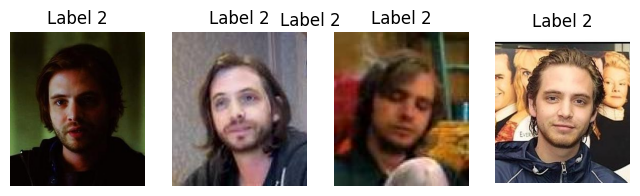

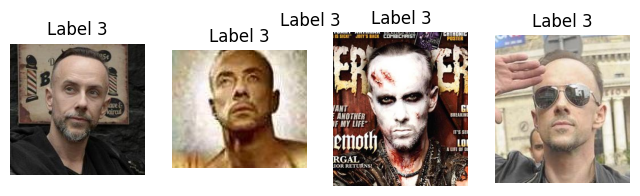

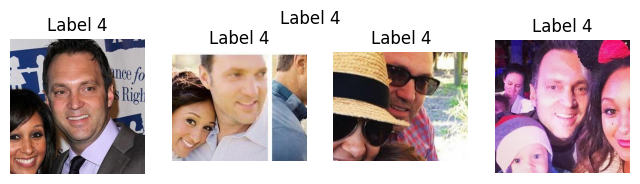

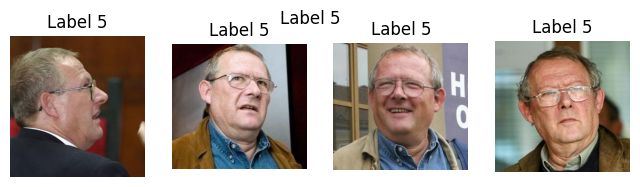

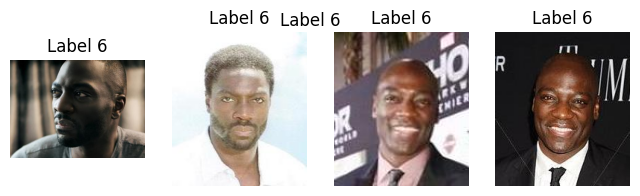

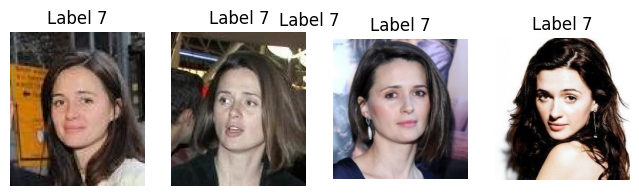

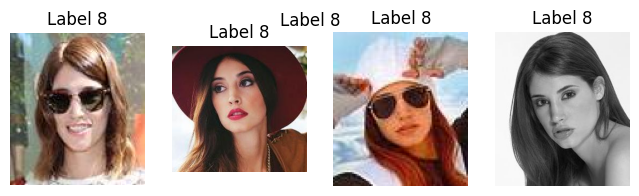

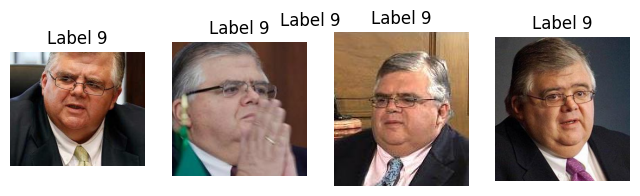

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
import random

# Group some paths by label
by_label_all = defaultdict(list)
for img_path, label in train_samples:
    by_label_all[label].append(img_path)

sample_labels = sorted(list(by_label_all.keys()))[:10]  # first 10 labels; change if needed
print("Sample labels:", sample_labels)

for lbl in sample_labels:
    paths = by_label_all[lbl][:4]  # up to 4 images
    plt.figure(figsize=(8, 2))
    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        plt.subplot(1, len(paths), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Label {lbl}")
    plt.suptitle(f"Label {lbl}")
    plt.show()


In [ ]:
label_to_gender = {
    0:0,
    1:0,
    2:0,
    3:0,
    4:0,
    5:0,
    6:0,
    7:1,
    8:1,
    9:0,
}


In [ ]:
gender_train_samples = []
gender_val_samples = []

for img_path, label in train_samples:
    if label in label_to_gender:
        gender = label_to_gender[label]
        gender_train_samples.append((img_path, gender))

for img_path, label in val_samples:
    if label in label_to_gender:
        gender = label_to_gender[label]
        gender_val_samples.append((img_path, gender))

print("Gender train samples:", len(gender_train_samples))
print("Gender val samples:", len(gender_val_samples))


Gender train samples: 2820
Gender val samples: 709


In [ ]:
from torch.utils.data import Dataset, DataLoader

class GenderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples      # list of (path, gender)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, gender = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, gender  # gender = 0 or 1


In [ ]:
gender_train_dataset = GenderDataset(gender_train_samples, transform=transform_train)
gender_val_dataset   = GenderDataset(gender_val_samples,   transform=transform_val)

BATCH_GENDER = 32

gender_train_loader = DataLoader(gender_train_dataset, batch_size=BATCH_GENDER, shuffle=True, num_workers=2)
gender_val_loader   = DataLoader(gender_val_dataset,   batch_size=BATCH_GENDER, shuffle=False, num_workers=2)

print("Gender train batches:", len(gender_train_loader))
print("Gender val batches:", len(gender_val_loader))


Gender train batches: 89
Gender val batches: 23


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class GenderNet(nn.Module):
    def __init__(self, embedding_model):
        super().__init__()
        self.embedding_model = embedding_model
        # Freeze embedding weights
        for p in self.embedding_model.parameters():
            p.requires_grad = False

        self.fc = nn.Linear(128, 2)  # 2 classes: male/female

    def forward(self, x):
        with torch.no_grad():
            emb = self.embedding_model(x)  # (B, 128)

        logits = self.fc(emb)  # (B, 2)
        return logits


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
gender_model = GenderNet(best_model).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_gender = torch.optim.Adam(gender_model.fc.parameters(), lr=1e-3)


In [ ]:
def train_gender_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, genders in loader:
        imgs = imgs.to(device)
        genders = genders.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, genders)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == genders).sum().item()
        total += imgs.size(0)

    avg_loss = running_loss / total
    acc = correct / total if total > 0 else 0.0
    print(f"Train loss: {avg_loss:.4f}, acc: {acc*100:.2f}%")
    return avg_loss, acc


def eval_gender(model, loader, criterion, device, tag="Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, genders in loader:
            imgs = imgs.to(device)
            genders = genders.to(device)

            logits = model(imgs)
            loss = criterion(logits, genders)

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == genders).sum().item()
            total += imgs.size(0)

    avg_loss = running_loss / total
    acc = correct / total if total > 0 else 0.0
    print(f"{tag} loss: {avg_loss:.4f}, acc: {acc*100:.2f}%")
    return avg_loss, acc


In [ ]:
EPOCHS_GENDER = 5

for epoch in range(1, EPOCHS_GENDER + 1):
    print(f"\n=== Gender Epoch {epoch}/{EPOCHS_GENDER} ===")
    train_gender_one_epoch(gender_model, gender_train_loader, optimizer_gender, criterion, device)
    eval_gender(gender_model, gender_val_loader, criterion, device)



=== Gender Epoch 1/5 ===
Train loss: 0.6058, acc: 74.26%
Val loss: 0.4819, acc: 95.63%

=== Gender Epoch 2/5 ===
Train loss: 0.4072, acc: 96.13%
Val loss: 0.3537, acc: 94.92%

=== Gender Epoch 3/5 ===
Train loss: 0.3034, acc: 96.56%
Val loss: 0.2592, acc: 97.46%

=== Gender Epoch 4/5 ===
Train loss: 0.2378, acc: 97.20%
Val loss: 0.2297, acc: 96.05%

=== Gender Epoch 5/5 ===
Train loss: 0.1996, acc: 96.88%
Val loss: 0.1799, acc: 97.60%


In [ ]:
# ============================
# CELL 1 — DEFINE EVERYTHING
# ============================

import io
from google.colab import files
from PIL import Image
import torch.nn.functional as F

# ---- Gender prediction function ----
def predict_gender(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    x = transform_val(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0]
        pred = torch.argmax(probs).item()

    label = "Male" if pred == 0 else "Female"
    print(f"Prediction: {label}  (Male prob={probs[0]:.3f}, Female prob={probs[1]:.3f})")
    return label, probs.cpu().numpy()


In [ ]:
# ============================
# CELL 2 — UPLOAD & PREDICT
# ============================

from google.colab import files

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nUser uploaded: {filename}")
        predict_gender(filename, gender_model, device)
else:
    print("No file uploaded.")


Saving srinivas_psp.jpg to srinivas_psp.jpg

User uploaded: srinivas_psp.jpg
Prediction: Male  (Male prob=0.937, Female prob=0.063)


In [ ]:
# ============================
# CELL 3 — SINGLE-IMAGE VIS
# ============================

import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

def predict_gender_with_plot(image_path, model, device):
    # Load image
    img = Image.open(image_path).convert("RGB")
    x = transform_val(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred = probs.argmax()

    label = "Male" if pred == 0 else "Female"
    print(f"Prediction: {label}  (Male={probs[0]:.3f}, Female={probs[1]:.3f})")

    # --- Visualization: image + bar chart ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Left: face image
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Input Image\nPredicted: {label}")

    # Right: probability bar chart
    axes[1].bar(["Male", "Female"], probs)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Probability")
    axes[1].set_title("Gender probabilities")
    for i, v in enumerate(probs):
        axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

    plt.tight_layout()
    plt.show()

    return label, probs


Saving srinivas_psp.jpg to srinivas_psp (1).jpg

User uploaded: srinivas_psp (1).jpg
Prediction: Male  (Male=0.937, Female=0.063)


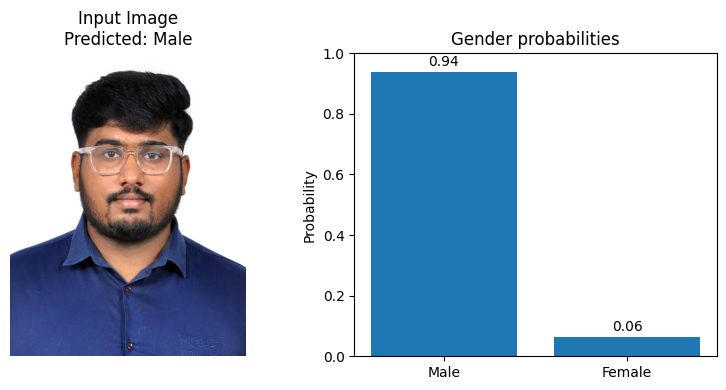

In [ ]:
# ============================
# CELL 2 — UPLOAD & PREDICT
# ============================

from google.colab import files

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nUser uploaded: {filename}")
        predict_gender_with_plot(filename, gender_model, device)
else:
    print("No file uploaded.")


Saving velibor-adzic-headshot.png to velibor-adzic-headshot.png

User uploaded: velibor-adzic-headshot.png
Prediction: Male  (Male=0.930, Female=0.070)


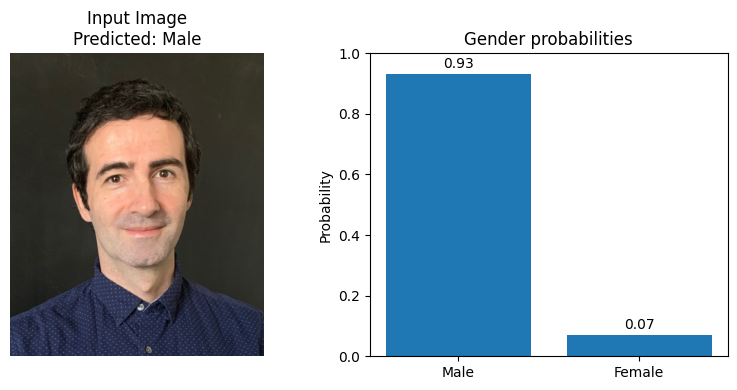

In [ ]:
from google.colab import files

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nUser uploaded: {filename}")
        predict_gender_with_plot(filename, gender_model, device)
else:
    print("No file uploaded.")


Saving pavlovic.jpg to pavlovic.jpg

User uploaded: pavlovic.jpg
Prediction: Female  (Male=0.284, Female=0.716)


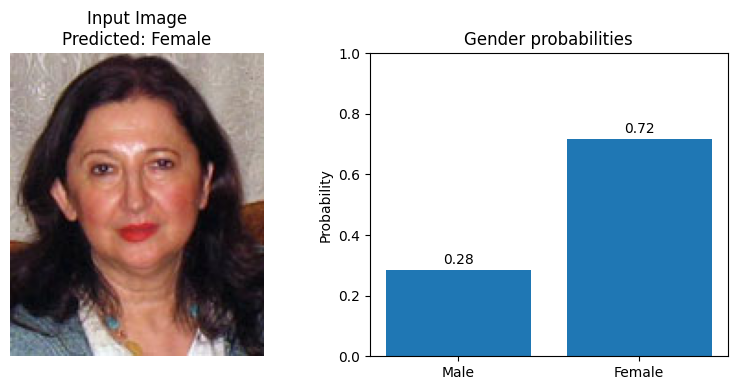

In [ ]:
# ============================
# CELL 2 — UPLOAD & PREDICT
# ============================

from google.colab import files

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nUser uploaded: {filename}")
        predict_gender_with_plot(filename, gender_model, device)
else:
    print("No file uploaded.")


Saving photo-raquel-assis.jpg to photo-raquel-assis.jpg

User uploaded: photo-raquel-assis.jpg
Prediction: Female  (Male=0.154, Female=0.846)


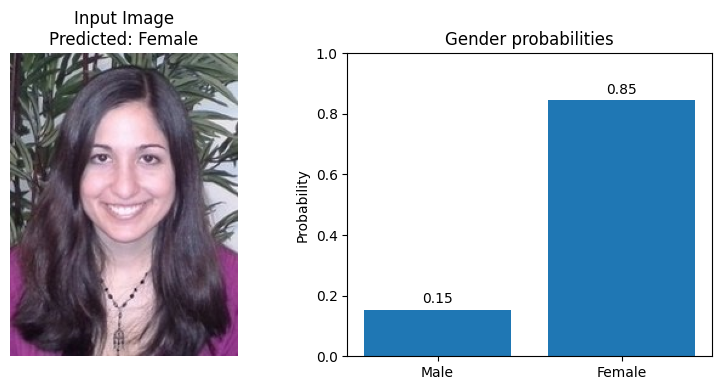

In [ ]:
# ============================
# CELL 2 — UPLOAD & PREDICT
# ============================

from google.colab import files

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f"\nUser uploaded: {filename}")
        predict_gender_with_plot(filename, gender_model, device)
else:
    print("No file uploaded.")


Classification report:
              precision    recall  f1-score   support

        Male       0.99      0.98      0.99       571
      Female       0.92      0.96      0.94       138

    accuracy                           0.98       709
   macro avg       0.96      0.97      0.96       709
weighted avg       0.98      0.98      0.98       709

Overall accuracy: 97.60%


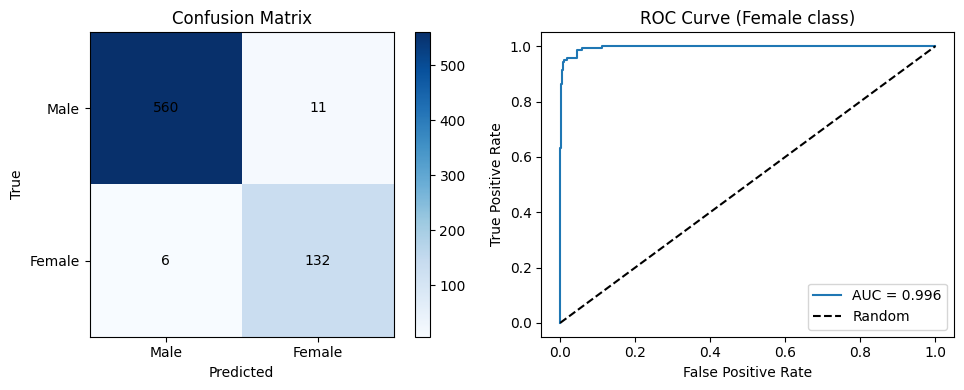

In [ ]:
# ============================
# CELL 4 — METRICS & GRAPHS
# ============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

gender_model.eval()

all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, genders in gender_val_loader:
        imgs = imgs.to(device)
        genders = genders.to(device)

        logits = gender_model(imgs)
        probs = F.softmax(logits, dim=1)  # (B, 2)

        all_labels.extend(genders.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # prob of class "Female"

all_labels = np.array(all_labels)          # 0=Male, 1=Female
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

# --- 1) Print basic metrics ---
print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=["Male", "Female"]))

acc = (all_preds == all_labels).mean()
print(f"Overall accuracy: {acc*100:.2f}%")

# --- 2) Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(["Male", "Female"])
ax[0].set_yticklabels(["Male", "Female"])
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax[0])

# --- 3) ROC curve ---
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax[1].plot([0, 1], [0, 1], "k--", label="Random")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve (Female class)")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
